# Forecasting Analysis

Modified from *Using Deep Learning for Flexible and Scalable Earthquake Forecasting*.
Reference: [Zenodo](https://zenodo.org/records/8161777)

## 1) Setup

In [1]:
import os
import sys
import functools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src
import src.utils.catalog_tests as catalog_tests
from src.train.config_setup import load_and_prepare_model
from src.utils.tpp_experiments import load_tpp_catalog, sample_tpp_forecasts
from src.utils.utils import set_seed
from src.utils.viz_sequences import visualize_sequence
from src.utils.bootstrap_ci import bootstrap_multi_model_metric_ci, SamplingMethod
from src.utils.bootstrap_presets import PairedBootstrapPreset

set_seed(0)
np.random.seed(0)
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0


## 2) Configuration (Multi-model)

In [2]:
import json

# External model-spec config for tpp comparison.
# You can switch directory/file/name below without editing model code.
MODEL_SPEC_CONFIG_DIR = PROJECT_ROOT / 'notebooks' / 'config' / 'model_specs' / 'tpp_comparison'
MODEL_SPEC_CONFIG_FILE = 'model_specs.tpp_comparison.v1.json'
MODEL_SPEC_CONFIG_NAME = 'default_em_eqf_recast_etas'

# Support multiple checkpoint roots. For relative checkpoint paths,
# resolver checks each root in order and uses the first existing file.
CHECKPOINT_SEARCH_ROOTS = [
    PROJECT_ROOT / 'checkpoints',
]


if not MODEL_SPEC_CONFIG_DIR.exists():
    raise FileNotFoundError(f'Model spec config dir not found: {MODEL_SPEC_CONFIG_DIR}')

MODEL_SPEC_CONFIG_PATH = MODEL_SPEC_CONFIG_DIR / MODEL_SPEC_CONFIG_FILE
if not MODEL_SPEC_CONFIG_PATH.exists():
    raise FileNotFoundError(f'Model spec config file not found: {MODEL_SPEC_CONFIG_PATH}')

with open(MODEL_SPEC_CONFIG_PATH, 'r', encoding='utf-8') as f:
    model_spec_catalog = json.load(f)

config_map = model_spec_catalog.get('configs', {})
if not isinstance(config_map, dict) or len(config_map) == 0:
    raise ValueError(
        f'Invalid config format in {MODEL_SPEC_CONFIG_PATH}: missing non-empty "configs".'
    )

available_config_names = sorted(config_map.keys())
print('Available model spec configs:')
for cfg_name in available_config_names:
    cfg = config_map.get(cfg_name, {})
    cfg_desc = cfg.get('description', '')
    cfg_models = cfg.get('models', [])
    cfg_model_count = len(cfg_models) if isinstance(cfg_models, list) else 0
    if cfg_desc:
        print(f'  - {cfg_name}: {cfg_desc} (models={cfg_model_count})')
    else:
        print(f'  - {cfg_name} (models={cfg_model_count})')

if MODEL_SPEC_CONFIG_NAME not in config_map:
    available = ', '.join(available_config_names)
    raise KeyError(
        f'Unknown MODEL_SPEC_CONFIG_NAME={MODEL_SPEC_CONFIG_NAME}. '
        f'Available: {available}'
    )

selected_model_spec_cfg = config_map[MODEL_SPEC_CONFIG_NAME]
raw_model_specs = selected_model_spec_cfg.get('models', [])
if not isinstance(raw_model_specs, list) or len(raw_model_specs) == 0:
    raise ValueError(
        f'Config "{MODEL_SPEC_CONFIG_NAME}" has no models in {MODEL_SPEC_CONFIG_PATH}.'
    )

for i, item in enumerate(raw_model_specs):
    if 'label' not in item or 'checkpoint_rel_path' not in item:
        raise KeyError(
            f'Invalid model item at index {i} in config "{MODEL_SPEC_CONFIG_NAME}". '
            'Each item must contain "label" and "checkpoint_rel_path".'
        )

checkpoint_search_roots = []
for root in CHECKPOINT_SEARCH_ROOTS:
    root_i = Path(root)
    if not root_i.is_absolute():
        root_i = PROJECT_ROOT / root_i
    checkpoint_search_roots.append(root_i)

if len(checkpoint_search_roots) == 0:
    raise ValueError('CHECKPOINT_SEARCH_ROOTS must contain at least one root directory.')


def resolve_checkpoint_path(checkpoint_rel_or_abs_path: str) -> Path:
    raw_path = Path(checkpoint_rel_or_abs_path)
    if raw_path.is_absolute():
        return raw_path

    # Backward compatibility: support old style "checkpoints/..." in config.
    if len(raw_path.parts) > 0 and raw_path.parts[0] == 'checkpoints':
        candidate = PROJECT_ROOT / raw_path
        if candidate.exists():
            return candidate

    for root_dir in checkpoint_search_roots:
        candidate = root_dir / raw_path
        if candidate.exists():
            return candidate

    # Keep deterministic output path even when file does not exist,
    # so downstream FileNotFoundError shows expected resolved location.
    return checkpoint_search_roots[0] / raw_path


MODEL_SPECS = []
for item in raw_model_specs:
    spec_i = {
        'label': item['label'],
        'checkpoint_path': resolve_checkpoint_path(item['checkpoint_rel_path']),
        'compile': bool(item.get('compile', True)),
    }
    if 'override_M_m' in item:
        spec_i['override_M_m'] = item['override_M_m']
    MODEL_SPECS.append(spec_i)

print(f'Loaded MODEL_SPECS config: {MODEL_SPEC_CONFIG_NAME}')
print(f'Model spec config file: {MODEL_SPEC_CONFIG_PATH}')
print('Checkpoint search roots:')
for root_i in checkpoint_search_roots:
    print(f'  - {root_i}')
if selected_model_spec_cfg.get('description'):
    print(f"Config description: {selected_model_spec_cfg['description']}")

for spec in MODEL_SPECS:
    print(f"[{spec['label']}] {spec['checkpoint_path']}")



Available model spec configs:
  - default_em_eqf_recast_etas: Default 3-model comparison: EM-EQF / RECAST / ETAS (models=3)
Loaded MODEL_SPECS config: default_em_eqf_recast_etas
Model spec config file: /root/autodl-tmp/em_eqf/notebooks/config/model_specs/tpp_comparison/model_specs.tpp_comparison.v1.json
Checkpoint search roots:
  - /root/autodl-tmp/em_eqf/checkpoints
Config description: Default 3-model comparison: EM-EQF / RECAST / ETAS
[EM-EQF] /root/autodl-tmp/em_eqf/checkpoints/mixer_tpp_20260206-102040/best_model_1.pth
[RECAST] /root/autodl-tmp/em_eqf/checkpoints/rtpp_20260506-173356/best_model_1.pth
[ETAS] /root/autodl-tmp/em_eqf/checkpoints/etas_20260507-143239/best_model_1.pth


## 3) Load Trained Models

In [3]:
loaded_models = []
base_args = None

for spec in MODEL_SPECS:
    ckpt_path = spec['checkpoint_path']
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

    model_i, args_i = load_and_prepare_model(
        checkpoint_path=ckpt_path,
        device=DEVICE,
        compile=bool(spec.get('compile', True)),
    )

    override_mm = spec.get('override_M_m', None)
    if override_mm is not None and hasattr(model_i, 'M_m'):
        model_i.M_m = torch.tensor(float(override_mm), device=DEVICE)

    loaded_models.append(
        {
            'label': spec['label'],
            'checkpoint_path': ckpt_path,
            'model': model_i,
            'args': args_i,
        }
    )

    if base_args is None:
        base_args = args_i
    elif args_i.dataset != base_args.dataset:
        raise ValueError(
            f"All models must use the same dataset for paired bootstrap. "
            f"Got {base_args.dataset} vs {args_i.dataset}."
        )

for item in loaded_models:
    print(f"Loaded: {item['label']} | model={item['args'].model} | dataset={item['args'].dataset}")


Loaded: EM-EQF | model=mixer_tpp | dataset=ChuanDian
Loaded: RECAST | model=rtpp | dataset=ChuanDian
Loaded: ETAS | model=etas | dataset=ChuanDian


## 4) Load Catalog and Visualize

Using catalog registry name: ChuanDian-Standard


<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

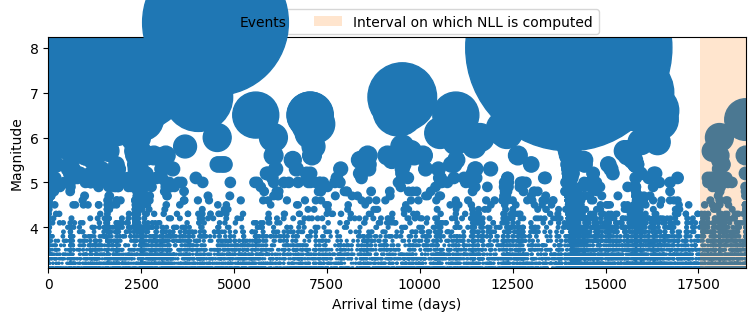

In [4]:
catalog_ds, registry_name, catalog_init_kwargs = load_tpp_catalog(
    base_args.dataset,
    base_dir=PROJECT_ROOT / 'data' / base_args.dataset,
    catalog_cfg=getattr(base_args, 'catalog_cfg', {}),
)
print(f'Using catalog registry name: {registry_name}')

train_seq = catalog_ds.train[0]
test_seq = catalog_ds.test[0]

visualize_sequence(test_seq, show_nll=True)


In [5]:
import src.utils.catalog_utils as catalog_utils

# Split test_seq using unlimited max_events so each window keeps original start.
test_seq_splits = catalog_utils.split_sequence(
    test_seq,
    mean_batch_size=getattr(base_args, 'mean_nll_events', 100),
    max_events=None,
)
print(f"Split test_seq into {len(test_seq_splits)} windows")
print(
    f"First split: t_start={test_seq_splits[0].t_start}, "
    f"t_nll_start={test_seq_splits[0].t_nll_start}, "
    f"num_events={test_seq_splits[0].num_events}"
)


Split test_seq into 11 windows
First split: t_start=0.0, t_nll_start=17532.0, num_events=10587


In [6]:
test_seq_splits

TppDataset(11)

## 5) Test Window Likelihood + Paired Bootstrap


In [7]:
from src.data import Batch

# Keep evaluation aligned with main.py test branch.
TEST_NLL_REDUCTION = getattr(base_args, 'loss_reduction', None)

# Evaluation metric(s) used by paired bootstrap + visualization.
# Supports single metric string or multiple metrics.
# Examples: 'nll_time' or ['nll_time', 'nll_total']
EVAL_METRICS = 'nll_time'

if isinstance(EVAL_METRICS, str):
    EVAL_METRIC_COLUMNS = [EVAL_METRICS]
else:
    EVAL_METRIC_COLUMNS = list(EVAL_METRICS)

if not EVAL_METRIC_COLUMNS:
    raise ValueError('EVAL_METRICS must contain at least one metric.')

EVAL_METRIC_COLUMNS = [
    metric if metric.startswith('nll_') else f'nll_{metric}'
    for metric in EVAL_METRIC_COLUMNS
]

BOOTSTRAP_SAMPLING_METHOD: SamplingMethod = 'block'  # 'iid' or 'block'
BOOTSTRAP_PRESET = PairedBootstrapPreset(
    sampling=BOOTSTRAP_SAMPLING_METHOD,
    ci=(2.5, 97.5),
    n_resamples_curve=400,
    n_resamples_metric=2000,
    block_size=max(1, int(round(np.sqrt(len(test_seq_splits))))),
    circular_block=True,
)

print(f'TEST_NLL_REDUCTION: {TEST_NLL_REDUCTION}')
print(f'EVAL_METRICS (resolved): {EVAL_METRIC_COLUMNS}')
print(f'BOOTSTRAP sampling={BOOTSTRAP_PRESET.sampling}, metric_resamples={BOOTSTRAP_PRESET.n_resamples_metric}, block_size={BOOTSTRAP_PRESET.block_size}')


TEST_NLL_REDUCTION: per_time
EVAL_METRICS (resolved): ['nll_time']
BOOTSTRAP sampling=block, metric_resamples=2000, block_size=3


In [8]:
def _model_nll_on_sequence(model_obj, seq, *, reduction=None):
    batch = Batch.from_list([seq]).to(DEVICE)

    nll_kwargs = {}
    if reduction is not None:
        nll_kwargs['reduction'] = reduction

    out = model_obj.nll_loss(batch, **nll_kwargs)

    if isinstance(out, dict):
        time_val = out.get('time', out.get('total'))
        total_val = out.get('total', time_val)
    else:
        time_val = out
        total_val = out

    return {
        'time': torch.as_tensor(time_val).detach().cpu().reshape(-1),
        'total': torch.as_tensor(total_val).detach().cpu().reshape(-1),
    }


window_rows = []
for i, seq in enumerate(test_seq_splits):
    base_row = {
        'window_idx': i,
        't_start': float(seq.t_start),
        't_nll_start': float(seq.t_nll_start),
        't_end': float(seq.t_end),
        'num_events': int(seq.num_events),
        'window_duration': float(seq.t_end - seq.t_start),
    }
    for item in loaded_models:
        out = _model_nll_on_sequence(item['model'], seq, reduction=TEST_NLL_REDUCTION)
        row = dict(base_row)
        row['label'] = item['label']
        for key, value in out.items():
            row[f'nll_{key}'] = float(value.mean().item())
        window_rows.append(row)

window_df = pd.DataFrame(window_rows)
if window_df.empty:
    raise ValueError('No test subwindows were generated.')

missing_metric_cols = [col for col in EVAL_METRIC_COLUMNS if col not in window_df.columns]
if missing_metric_cols:
    available_metric_cols = sorted([col for col in window_df.columns if col.startswith('nll_')])
    raise ValueError(
        f'Unknown metric columns in EVAL_METRICS: {missing_metric_cols}. '
        f'Available metric columns: {available_metric_cols}'
    )

preview_cols = ['label', 'window_idx', 'num_events', *EVAL_METRIC_COLUMNS]
print(window_df[preview_cols].head())
print('models:', sorted(window_df['label'].unique().tolist()))
print('windows per model:')
print(window_df.groupby('label')['window_idx'].nunique())


    label  window_idx  num_events  nll_time
0  EM-EQF           0       10587  0.800014
1  RECAST           0       10587  0.812663
2    ETAS           0       10587  0.808827
3  EM-EQF           1       10648  0.558611
4  RECAST           1       10648  0.536112
models: ['EM-EQF', 'ETAS', 'RECAST']
windows per model:
label
EM-EQF    11
ETAS      11
RECAST    11
Name: window_idx, dtype: int64


In [9]:
# Build paired matrix: each row is a subwindow, each column is a model.
model_labels = [item['label'] for item in loaded_models]
BOOTSTRAP_BASELINE_MODEL = None  # None => use first model label
effective_baseline_model = BOOTSTRAP_BASELINE_MODEL or (model_labels[0] if len(model_labels) > 0 else None)

paired_results_by_metric = {}
paired_bootstrap_summaries = []
paired_delta_summaries = []

for metric_col in EVAL_METRIC_COLUMNS:
    pivot_metric = (
        window_df.pivot_table(index='window_idx', columns='label', values=metric_col, aggfunc='first')
        .reindex(columns=model_labels)
        .sort_index()
    )

    if pivot_metric.isna().any().any():
        missing = int(pivot_metric.isna().sum().sum())
        raise ValueError(
            f'Paired bootstrap requires complete aligned windows for {metric_col}. '
            f'Missing cells: {missing}'
        )

    y_true_dummy = np.zeros(len(pivot_metric), dtype=np.int64)
    model_predictions = {label: pivot_metric[label].to_numpy(dtype=float) for label in model_labels}

    bootstrap_kwargs = {
        'y_true': y_true_dummy,
        'model_predictions': model_predictions,
        'metric': lambda y_true, y_pred: float(np.mean(y_pred)),
        'task': 'regression',
        'config': BOOTSTRAP_PRESET.metric_config(seed=123),
    }
    if len(model_labels) >= 3:
        if effective_baseline_model is None:
            raise ValueError('No baseline model available for >=3 models.')
        bootstrap_kwargs['baseline_model'] = effective_baseline_model

    paired_result = bootstrap_multi_model_metric_ci(**bootstrap_kwargs)
    paired_results_by_metric[metric_col] = paired_result

    summary_rows = []
    for label in model_labels:
        r = paired_result.model_results[label]
        summary_rows.append(
            {
                'label': label,
                'point_estimate': r.point_estimate,
                'ci_low': r.ci_low,
                'ci_high': r.ci_high,
                'valid_resamples': r.valid_resamples,
                'total_resamples': r.total_resamples,
            }
        )

    metric_bootstrap_summary = pd.DataFrame(summary_rows)
    metric_bootstrap_summary.insert(0, 'metric', metric_col)
    paired_bootstrap_summaries.append(metric_bootstrap_summary)

    print(f'--- Paired bootstrap: window-mean {metric_col} ---')
    if len(model_labels) >= 3:
        print(f'Paired bootstrap baseline: {effective_baseline_model}')
    print(metric_bootstrap_summary.to_string(index=False))

    if len(model_labels) >= 2:
        delta_rows = []
        for (left, right), r in paired_result.pairwise_deltas.items():
            delta_rows.append(
                {
                    'left_model': left,
                    'right_model': right,
                    'delta_name': f'{left} - {right}',
                    'delta_point_estimate': r.point_estimate,
                    'ci_low': r.ci_low,
                    'ci_high': r.ci_high,
                    'valid_resamples': r.valid_resamples,
                    'total_resamples': r.total_resamples,
                }
            )
        metric_delta_summary = pd.DataFrame(delta_rows)
        metric_delta_summary.insert(0, 'metric', metric_col)
        paired_delta_summaries.append(metric_delta_summary)
        print('\n--- Paired bootstrap deltas ---')
        print(metric_delta_summary.to_string(index=False))
    else:
        print('Only one model loaded; skipping pairwise delta table.')

paired_bootstrap_summary = (
    pd.concat(paired_bootstrap_summaries, ignore_index=True)
    if paired_bootstrap_summaries
    else pd.DataFrame()
)
paired_delta_summary = (
    pd.concat(paired_delta_summaries, ignore_index=True)
    if paired_delta_summaries
    else pd.DataFrame()
)

paired_bootstrap_wide_df = (
    paired_bootstrap_summary
    .pivot_table(index='metric', columns='label', values='point_estimate', aggfunc='first')
    .reset_index()
    if not paired_bootstrap_summary.empty
    else pd.DataFrame()
)

EXPORT_BOOTSTRAP = True
BOOTSTRAP_MODE = f'paired_{BOOTSTRAP_PRESET.sampling}'

# Create dataset-specific subdir to avoid overwriting across datasets.
export_dataset = str(
    getattr(base_args, 'dataset', None)
    or getattr(globals().get('args_i', None), 'dataset', None)
    or 'unknown_dataset'
)
export_dataset = export_dataset.replace('\\', '_').replace('/', '_').replace(os.sep, '_')
BOOTSTRAP_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'metrics' / 'tpp_comparison' / export_dataset
BOOTSTRAP_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
BOOTSTRAP_EXPORT_STEM = f'tpp_comparison_bootstrap_metrics_{BOOTSTRAP_MODE}'

if EXPORT_BOOTSTRAP:
    ts = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')

    long_csv_path = BOOTSTRAP_EXPORT_DIR / f'{BOOTSTRAP_EXPORT_STEM}_long_{ts}.csv'
    wide_csv_path = BOOTSTRAP_EXPORT_DIR / f'{BOOTSTRAP_EXPORT_STEM}_wide_{ts}.csv'
    pair_delta_csv_path = BOOTSTRAP_EXPORT_DIR / f'{BOOTSTRAP_EXPORT_STEM}_pairwise_delta_{ts}.csv'
    window_csv_path = BOOTSTRAP_EXPORT_DIR / f'{BOOTSTRAP_EXPORT_STEM}_window_{ts}.csv'
    json_path = BOOTSTRAP_EXPORT_DIR / f'{BOOTSTRAP_EXPORT_STEM}_long_{ts}.json'
    pair_delta_json_path = BOOTSTRAP_EXPORT_DIR / f'{BOOTSTRAP_EXPORT_STEM}_pairwise_delta_{ts}.json'

    paired_bootstrap_summary.to_csv(long_csv_path, index=False)
    paired_bootstrap_wide_df.to_csv(wide_csv_path, index=False)
    paired_delta_summary.to_csv(pair_delta_csv_path, index=False)
    window_df.to_csv(window_csv_path, index=False)

    paired_bootstrap_summary.to_json(json_path, orient='records', force_ascii=False, indent=2)
    paired_delta_summary.to_json(pair_delta_json_path, orient='records', force_ascii=False, indent=2)

    print(f'Bootstrap long CSV exported: {long_csv_path}')
    print(f'Bootstrap wide CSV exported: {wide_csv_path}')
    print(f'Bootstrap pairwise delta CSV exported: {pair_delta_csv_path}')
    print(f'Per-window metrics CSV exported: {window_csv_path}')
    print(f'Bootstrap JSON exported: {json_path}')
    print(f'Bootstrap pairwise delta JSON exported: {pair_delta_json_path}')
else:
    print('EXPORT_BOOTSTRAP=False, skip export.')




--- Paired bootstrap: window-mean nll_time ---
Paired bootstrap baseline: EM-EQF
  metric  label  point_estimate   ci_low  ci_high  valid_resamples  total_resamples
nll_time EM-EQF        0.581701 0.271046 0.896887             2000             2000
nll_time RECAST        0.561347 0.236773 0.897448             2000             2000
nll_time   ETAS        0.598726 0.285749 0.917998             2000             2000

--- Paired bootstrap deltas ---
  metric left_model right_model      delta_name  delta_point_estimate    ci_low  ci_high  valid_resamples  total_resamples
nll_time     RECAST      EM-EQF RECAST - EM-EQF             -0.020354 -0.054007 0.007302             2000             2000
nll_time       ETAS      EM-EQF   ETAS - EM-EQF              0.017024  0.005073 0.027582             2000             2000
Bootstrap long CSV exported: /root/autodl-tmp/em_eqf/notebooks/metrics/tpp_comparison/ChuanDian/tpp_comparison_bootstrap_metrics_paired_block_long_20260511_172030.csv
Bootstrap wide

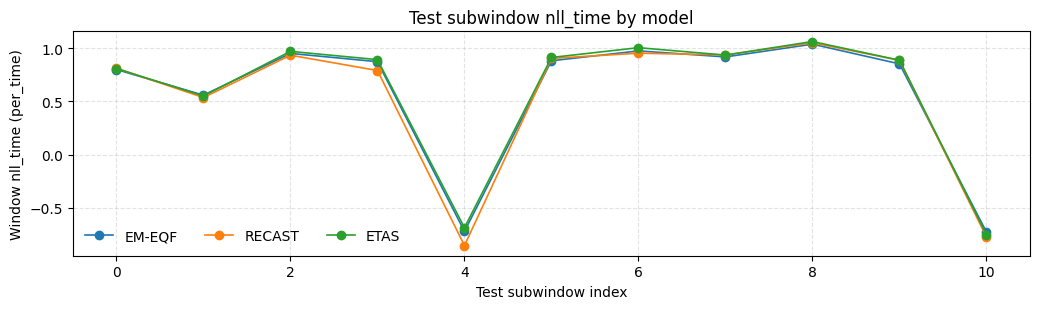

In [10]:
# Optional: visualize per-window NLL for all models on selected metrics.
for metric_col in EVAL_METRIC_COLUMNS:
    fig, ax = plt.subplots(figsize=(10.5, 3.2))
    for label in model_labels:
        sub = window_df[window_df['label'] == label].sort_values('window_idx')
        ax.plot(sub['window_idx'], sub[metric_col], marker='o', linewidth=1.2, label=label)

    ax.set_xlabel('Test subwindow index')
    ax.set_ylabel(f'Window {metric_col} ({TEST_NLL_REDUCTION})')
    ax.set_title(f'Test subwindow {metric_col} by model')
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(frameon=False, ncol=min(3, max(1, len(model_labels))))
    plt.tight_layout()
    plt.show()
